# 🏦 PreDelinq AI — Phase 3: Model Development, Evaluation & Credit Risk Scoring

## Project Context

Phase 1 (EDA) and Phase 2 (Feature Engineering) are complete. The cleaned, aggregated `final_feature_table.csv` is ready.

**Phase 3 Objective:** Build a complete banking-grade delinquency prediction system:
- Train & compare 5 industry-standard models
- Generate Probability of Default (PD) scores for every customer
- Create business-ready risk segments
- Deliver SHAP-based explainability for regulatory transparency

> **Scope:** Model Development, Evaluation, Explainability, Risk Scoring.  
> **Excluded:** Deep Learning, Neural Networks, AutoML, Stacking Ensembles.


---
## SECTION 1 — Environment Setup

**What we are doing:** Importing all required libraries for data processing, modeling, evaluation, and explainability.

**Why we are doing it:** A single, centralized import block ensures reproducibility and makes dependency auditing straightforward — a requirement in regulated banking environments.

**Banking Interpretation:** Regulatory frameworks (Basel III/IV, SR 11-7) require that model development environments be fully documented and reproducible. Setting a global `RANDOM_STATE` ensures that any auditor can replicate our exact results.

**Expected Output:** Confirmation that all libraries are loaded and the random seed is set.


In [1]:
# ============================================================
# SECTION 1 — Environment Setup
# ============================================================

# --- Core ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, gc, pickle, time

# --- Scikit-learn ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, precision_recall_curve,
    average_precision_score, classification_report
)

# --- Gradient Boosting ---
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# --- Explainability ---
import shap

# --- Settings ---
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 150)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Banking Color Palette ---
COLORS = {
    'safe':    '#1a73e8',   # Blue
    'risky':   '#ea4335',   # Red
    'neutral': '#5f6368',   # Gray
    'accent':  '#34a853',   # Green
    'purple':  '#9334e6',   # Purple
    'orange':  '#fa7b17',   # Orange
}
PALETTE = [COLORS['safe'], COLORS['risky']]

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')

# Master dict to store all model results
MODEL_RESULTS = {}

print('\u2705 Environment Setup Complete.')
print(f'   Random State: {RANDOM_STATE}')


✅ Environment Setup Complete.
   Random State: 42


---
## SECTION 2 — Load Final Feature Table

**What we are doing:** Loading the engineered feature matrix produced in Phase 2.

**Why we are doing it:** This is the single source of truth for modeling — one row per customer, with all aggregated bureau, installment, credit card, and application features.

**Banking Interpretation:** The feature table represents a 360-degree view of each borrower, combining demographic data, financial ratios, external bureau scores, and historical repayment behavior.

**Expected Output:** Dataset shape, memory usage, and target distribution summary.


In [2]:
# ============================================================
# SECTION 2 — Load Final Feature Table
# ============================================================

DATA_PATH = '../processed/final_feature_table.csv'
df = pd.read_csv(DATA_PATH)

mem_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f'Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory Usage:  {mem_mb:.2f} MB')

print('\nTarget Distribution:')
target_dist = df['TARGET'].value_counts()
for val, cnt in target_dist.items():
    pct = cnt / len(df) * 100
    label = 'Repaid (Safe)' if val == 0 else 'Defaulted (Risky)'
    print(f'  TARGET={val} [{label}]: {cnt:>8,}  ({pct:.2f}%)')

# --- Separate features and target ---
y = df['TARGET'].copy()
X = df.drop(columns=['TARGET', 'SK_ID_CURR'], errors='ignore').copy()

# --- Convert boolean columns to int ---
bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

# --- Convert remaining object columns to numeric codes ---
obj_cols = X.select_dtypes(include=['object']).columns.tolist()
if obj_cols:
    print(f'\nConverting {len(obj_cols)} remaining object columns to numeric...')
    for col in obj_cols:
        X[col] = pd.Categorical(X[col]).codes

# --- Replace infinities with NaN ---
X.replace([np.inf, -np.inf], np.nan, inplace=True)

print(f'\nFeature matrix X: {X.shape}')
print(f'Target vector  y: {y.shape}')


Dataset Shape: 307,511 rows x 195 columns
Memory Usage:  404.12 MB

Target Distribution:
  TARGET=0 [Repaid (Safe)]:  282,686  (91.93%)
  TARGET=1 [Defaulted (Risky)]:   24,825  (8.07%)

Feature matrix X: (307511, 193)
Target vector  y: (307511,)


---
## SECTION 3 — Feature Quality Assessment Before Modeling

**What we are doing:** Auditing the feature matrix for missing values, constant features, and highly correlated pairs.

**Why we are doing it:**
- **Constant features** (only one unique value) provide zero predictive power and waste compute.
- **High correlations** (> 0.95) indicate redundancy. We flag but do NOT auto-remove, as tree-based models handle multicollinearity gracefully.

**Banking Interpretation:** Feature quality directly impacts model reliability. Regulators expect a documented feature audit trail before model deployment.

**Expected Output:** Feature quality report with actionable findings.


In [3]:
# ============================================================
# SECTION 3 — Feature Quality Assessment
# ============================================================

print('=' * 60)
print('FEATURE QUALITY ASSESSMENT')
print('=' * 60)

# --- 1. Missing Value Audit ---
missing = X.isnull().sum()
missing_pct = (missing / len(X) * 100).round(2)
missing_report = pd.DataFrame({'Missing': missing, 'Pct': missing_pct})
missing_report = missing_report[missing_report['Missing'] > 0].sort_values('Pct', ascending=False)

print(f'\n[1] Missing Values:')
print(f'    Columns with missing: {len(missing_report)}')
print(f'    Total missing cells:  {missing.sum():,}')
if len(missing_report) > 0:
    print(f'    Top 5 missing columns:')
    display(missing_report.head())

# --- 2. Constant Feature Detection (nunique <= 1) ---
nunique = X.nunique()
constant_cols = nunique[nunique <= 1].index.tolist()
print(f'\n[2] Constant Features (nunique <= 1): {len(constant_cols)}')
if constant_cols:
    print(f'    Removing: {constant_cols}')
    X.drop(columns=constant_cols, inplace=True)

# --- 3. High Correlation Detection (> 0.95) ---
print(f'\n[3] High Correlation Detection (threshold > 0.95)...')
# Use only numeric, non-null subset for speed
numeric_X = X.select_dtypes(include=[np.number])
# Sample for speed if dataset is very large
if len(numeric_X) > 50000:
    sample_corr = numeric_X.sample(50000, random_state=RANDOM_STATE).corr().abs()
else:
    sample_corr = numeric_X.corr().abs()

upper_tri = sample_corr.where(np.triu(np.ones(sample_corr.shape), k=1).astype(bool))
high_corr_pairs = []
for col in upper_tri.columns:
    corr_cols = upper_tri.index[upper_tri[col] > 0.95].tolist()
    for c in corr_cols:
        high_corr_pairs.append((c, col, round(sample_corr.loc[c, col], 4)))

print(f'    Highly correlated pairs found: {len(high_corr_pairs)}')
if high_corr_pairs:
    hc_df = pd.DataFrame(high_corr_pairs, columns=['Feature_1', 'Feature_2', 'Correlation'])
    display(hc_df.head(10))
    print('    [INFO] Flagged only. NOT auto-removed (tree models handle this).')

print(f'\nFinal feature matrix shape: {X.shape}')


FEATURE QUALITY ASSESSMENT

[1] Missing Values:
    Columns with missing: 111
    Total missing cells:  11,044,882
    Top 5 missing columns:


,Missing,Pct
cc_max_utilization,221475,72.02
cc_avg_utilization,221475,72.02
cc_avg_balance,220606,71.74
cc_avg_drawings,220606,71.74
cc_avg_credit_limit,220606,71.74



[2] Constant Features (nunique <= 1): 0

[3] High Correlation Detection (threshold > 0.95)...
    Highly correlated pairs found: 65


,Feature_1,Feature_2,Correlation
0,AMT_CREDIT,AMT_GOODS_PRICE,0.9869
1,DAYS_EMPLOYED,FLAG_EMP_PHONE,0.9998
2,APARTMENTS_AVG,LIVINGAPARTMENTS_AVG,0.9551
3,APARTMENTS_AVG,APARTMENTS_MODE,0.9781
4,BASEMENTAREA_AVG,BASEMENTAREA_MODE,0.9743
5,YEARS_BEGINEXPLUATATION_AVG,YEARS_BEGINEXPLUATATION_MODE,0.9684
6,YEARS_BUILD_AVG,YEARS_BUILD_MODE,0.9878
7,COMMONAREA_AVG,COMMONAREA_MODE,0.9789
8,ELEVATORS_AVG,ELEVATORS_MODE,0.9798
9,ENTRANCES_AVG,ENTRANCES_MODE,0.9778


    [INFO] Flagged only. NOT auto-removed (tree models handle this).

Final feature matrix shape: (307511, 193)


---
## SECTION 4 — Train-Test Split

**What we are doing:** Splitting the data into 80% training and 20% test sets with stratification.

**Why we are doing it:** Stratified splitting preserves the class ratio (~92% safe, ~8% risky) in both sets, preventing evaluation bias.

**Banking Interpretation:** An unrepresentative test set could lead to dangerously optimistic performance estimates. In production banking, model validation teams require that holdout sets mirror the portfolio's true default rate.

**Expected Output:** Leakage-free train/test datasets with confirmed target distributions.


In [4]:
# ============================================================
# SECTION 4 — Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print('Train-Test Split Complete')
print(f'  Train: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'  Test:  {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)')

print(f'\n  Train TARGET distribution:')
for val, cnt in y_train.value_counts().items():
    print(f'    {val}: {cnt:,} ({cnt/len(y_train)*100:.2f}%)')

print(f'\n  Test TARGET distribution:')
for val, cnt in y_test.value_counts().items():
    print(f'    {val}: {cnt:,} ({cnt/len(y_test)*100:.2f}%)')


Train-Test Split Complete
  Train: 246,008 samples (80.0%)
  Test:  61,503 samples (20.0%)

  Train TARGET distribution:
    0: 226,148 (91.93%)
    1: 19,860 (8.07%)

  Test TARGET distribution:
    0: 56,538 (91.93%)
    1: 4,965 (8.07%)


---
## SECTION 5 — Class Imbalance Assessment

**What we are doing:** Quantifying and visualizing the class imbalance in our training data.

**Why we are doing it:** Credit default prediction is inherently imbalanced (~8% default rate). Standard accuracy is misleading — a model predicting 'Safe' for everyone achieves ~92% accuracy but catches zero defaults.

**Banking Interpretation:** The cost of missing a default (False Negative) is vastly higher than flagging a good customer (False Positive). This asymmetry must inform our choice of metrics (ROC-AUC, PR-AUC, Recall) over raw accuracy.

**Expected Output:** Class imbalance visualization and default rate report.


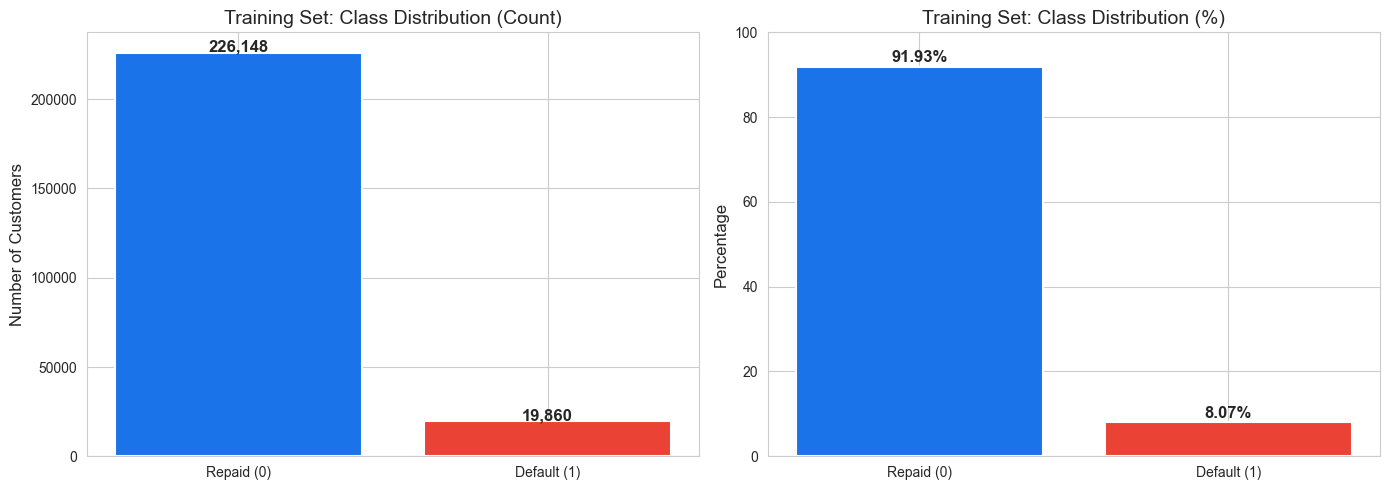

Default Rate: 8.07%
Imbalance Ratio (Safe:Risky): 11.4:1

[INFO] SMOTE is NOT applied. Tree-based models will use built-in class weighting.


In [5]:
# ============================================================
# SECTION 5 — Class Imbalance Assessment
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Bar Chart ---
counts = y_train.value_counts()
labels = ['Repaid (0)', 'Default (1)']
bars = axes[0].bar(labels, counts.values, color=PALETTE, edgecolor='white', linewidth=1.5)
axes[0].set_title('Training Set: Class Distribution (Count)', fontsize=14)
axes[0].set_ylabel('Number of Customers')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', fontsize=12, fontweight='bold')

# --- Percentage Chart ---
pcts = y_train.value_counts(normalize=True) * 100
bars2 = axes[1].bar(labels, pcts.values, color=PALETTE, edgecolor='white', linewidth=1.5)
axes[1].set_title('Training Set: Class Distribution (%)', fontsize=14)
axes[1].set_ylabel('Percentage')
axes[1].set_ylim(0, 100)
for bar, val in zip(bars2, pcts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.2f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

default_rate = y_train.mean() * 100
imbalance_ratio = counts[0] / counts[1]
print(f'Default Rate: {default_rate:.2f}%')
print(f'Imbalance Ratio (Safe:Risky): {imbalance_ratio:.1f}:1')
print('\n[INFO] SMOTE is NOT applied. Tree-based models will use built-in class weighting.')


---
### Model Evaluation Helper Function

A reusable function to evaluate every model consistently and store results.


In [6]:
# ============================================================
# Reusable Model Evaluation Function
# ============================================================

def evaluate_model(model_name, model, X_tr, X_te, y_tr, y_te,
                   scale=False, store=True):
    """
    Train, predict, and evaluate a model.
    Returns a dict of metrics.
    """
    start = time.time()

    # Optional scaling (for Logistic Regression)
    if scale:
        scaler = StandardScaler()
        X_tr_m = pd.DataFrame(scaler.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
        X_te_m = pd.DataFrame(scaler.transform(X_te), columns=X_te.columns, index=X_te.index)
        # Fill NaN after scaling
        X_tr_m.fillna(0, inplace=True)
        X_te_m.fillna(0, inplace=True)
    else:
        X_tr_m = X_tr
        X_te_m = X_te

    # Train
    model.fit(X_tr_m, y_tr)
    elapsed = time.time() - start

    # Predict
    y_pred = model.predict(X_te_m)
    y_prob = model.predict_proba(X_te_m)[:, 1]

    # Metrics
    metrics = {
        'Model': model_name,
        'ROC_AUC': roc_auc_score(y_te, y_prob),
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall': recall_score(y_te, y_pred, zero_division=0),
        'F1': f1_score(y_te, y_pred, zero_division=0),
        'PR_AUC': average_precision_score(y_te, y_prob),
        'Train_Time_s': round(elapsed, 2)
    }

    # Print
    print('=' * 60)
    print(f'  {model_name} — Evaluation Results')
    print('=' * 60)
    for k, v in metrics.items():
        if k != 'Model':
            print(f'  {k:<15s}: {v:.4f}' if isinstance(v, float) else f'  {k:<15s}: {v}')

    # Confusion Matrix
    cm = confusion_matrix(y_te, y_pred)
    print(f'\n  Confusion Matrix:')
    print(f'    TN={cm[0,0]:,}  FP={cm[0,1]:,}')
    print(f'    FN={cm[1,0]:,}  TP={cm[1,1]:,}')

    # Store
    if store:
        MODEL_RESULTS[model_name] = {
            'metrics': metrics,
            'model': model,
            'y_prob': y_prob,
            'y_pred': y_pred,
        }

    return metrics

print('\u2705 Evaluation helper ready.')


✅ Evaluation helper ready.


---
## SECTION 6 — Baseline Logistic Regression

**What we are doing:** Training a Logistic Regression with StandardScaler preprocessing as the baseline model.

**Why we are doing it:** Logistic Regression is the gold standard baseline in credit risk. It is fully transparent, easily interpretable, and regulatory-friendly. All subsequent models are compared against this benchmark.

**Banking Interpretation:** Many banks still use Logistic Regression as their primary scorecard model because regulators can directly inspect the coefficients to understand risk drivers. It serves as our interpretability floor.

**Expected Output:** Baseline ROC-AUC, confusion matrix, and ROC curve.


  Logistic Regression — Evaluation Results
  ROC_AUC        : 0.7669
  Accuracy       : 0.7014
  Precision      : 0.1701
  Recall         : 0.6961
  F1             : 0.2734
  PR_AUC         : 0.2524
  Train_Time_s   : 18.2500

  Confusion Matrix:
    TN=39,680  FP=16,858
    FN=1,509  TP=3,456


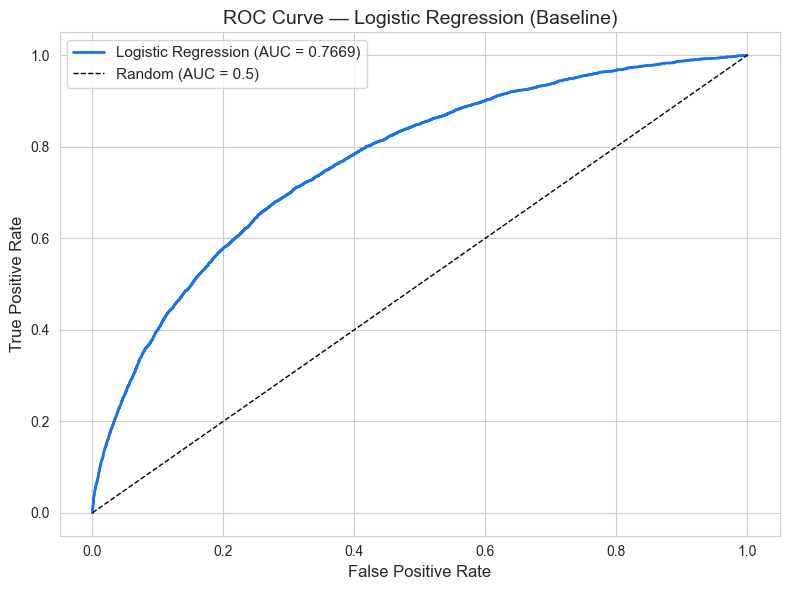

237

In [7]:
# ============================================================
# SECTION 6 — Logistic Regression (Baseline)
# ============================================================

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',    # Handle imbalance via class weights
    random_state=RANDOM_STATE,
    solver='lbfgs',
    n_jobs=-1
)

lr_metrics = evaluate_model('Logistic Regression', lr_model,
                            X_train, X_test, y_train, y_test, scale=True)

# --- ROC Curve ---
y_prob_lr = MODEL_RESULTS['Logistic Regression']['y_prob']
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color=COLORS['safe'], linewidth=2,
        label=f'Logistic Regression (AUC = {lr_metrics["ROC_AUC"]:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression (Baseline)', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

gc.collect()


---
## SECTION 7 — Random Forest Model

**What we are doing:** Training a Random Forest classifier to capture non-linear risk relationships.

**Why we are doing it:** Random Forest is an ensemble of decision trees that naturally handles feature interactions, missing values, and mixed data types without explicit preprocessing.

**Banking Interpretation:** Random Forest captures complex, non-linear dependencies (e.g., 'high income AND high utilization' patterns) that Logistic Regression cannot model. Its built-in feature importance ranking helps risk analysts identify the most predictive variables.

**Expected Output:** Model performance and top 20 feature importances.


  Random Forest — Evaluation Results
  ROC_AUC        : 0.7601
  Accuracy       : 0.7294
  Precision      : 0.1790
  Recall         : 0.6560
  F1             : 0.2813
  PR_AUC         : 0.2474
  Train_Time_s   : 70.7500

  Confusion Matrix:
    TN=41,603  FP=14,935
    FN=1,708  TP=3,257


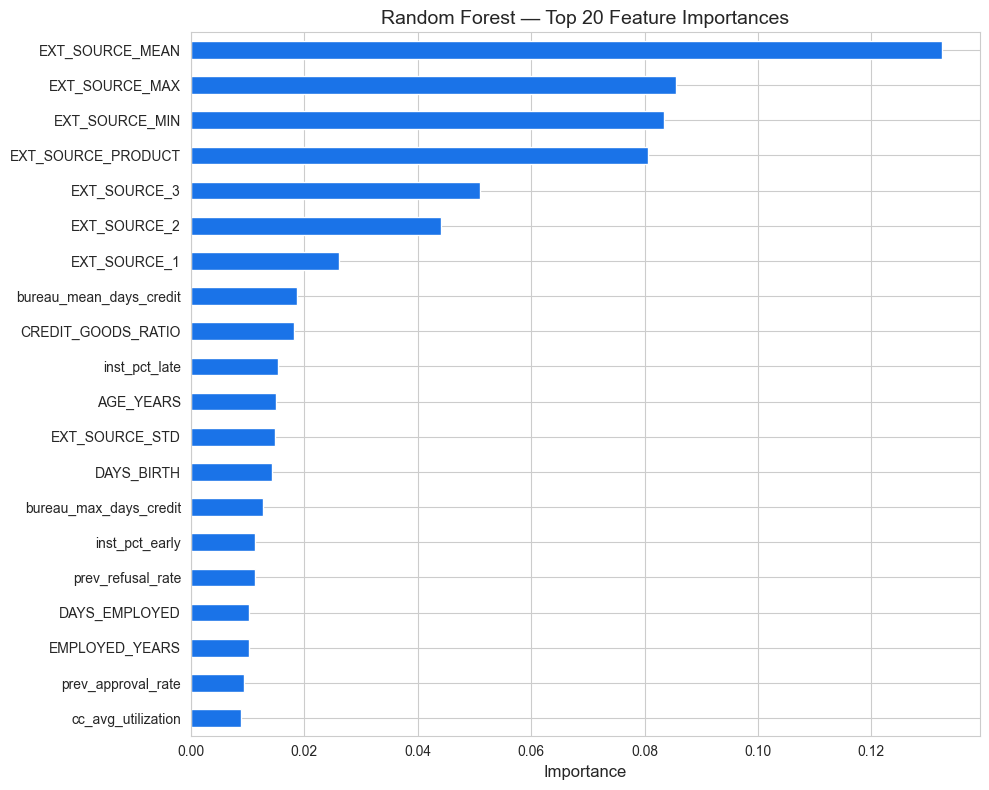

3901

In [8]:
# ============================================================
# SECTION 7 — Random Forest
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_metrics = evaluate_model('Random Forest', rf_model,
                            X_train, X_test, y_train, y_test)

# --- Top 20 Feature Importances ---
rf_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns)
rf_imp_top = rf_imp.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 8))
rf_imp_top.sort_values().plot.barh(ax=ax, color=COLORS['safe'], edgecolor='white')
ax.set_title('Random Forest — Top 20 Feature Importances', fontsize=14)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

gc.collect()


---
## SECTION 8 — XGBoost Model

**What we are doing:** Training an XGBoost (Extreme Gradient Boosting) classifier, the industry-standard model for structured credit risk data.

**Why we are doing it:** XGBoost builds trees sequentially, with each new tree correcting the errors of the previous ones. It excels at capturing complex feature interactions and is widely regarded as the top performer on tabular banking datasets.

**Banking Interpretation:** XGBoost is the most commonly used model in Kaggle credit risk competitions and is increasingly adopted by fintechs and large banks for PD/LGD modeling. Its `scale_pos_weight` parameter directly addresses the class imbalance problem.

**Expected Output:** ROC-AUC, PR-AUC, ROC & Precision-Recall curves, top 25 features.


  XGBoost — Evaluation Results
  ROC_AUC        : 0.7793
  Accuracy       : 0.7654
  Precision      : 0.2007
  Recall         : 0.6393
  F1             : 0.3055
  PR_AUC         : 0.2748
  Train_Time_s   : 21.5800

  Confusion Matrix:
    TN=43,900  FP=12,638
    FN=1,791  TP=3,174


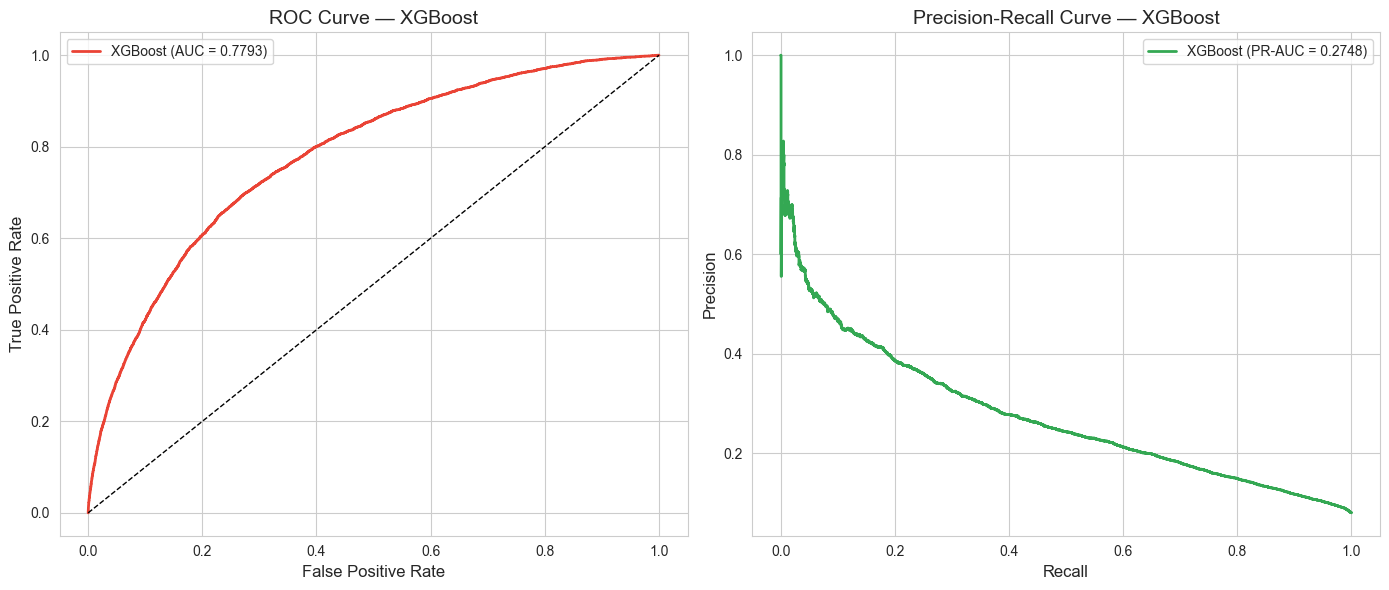

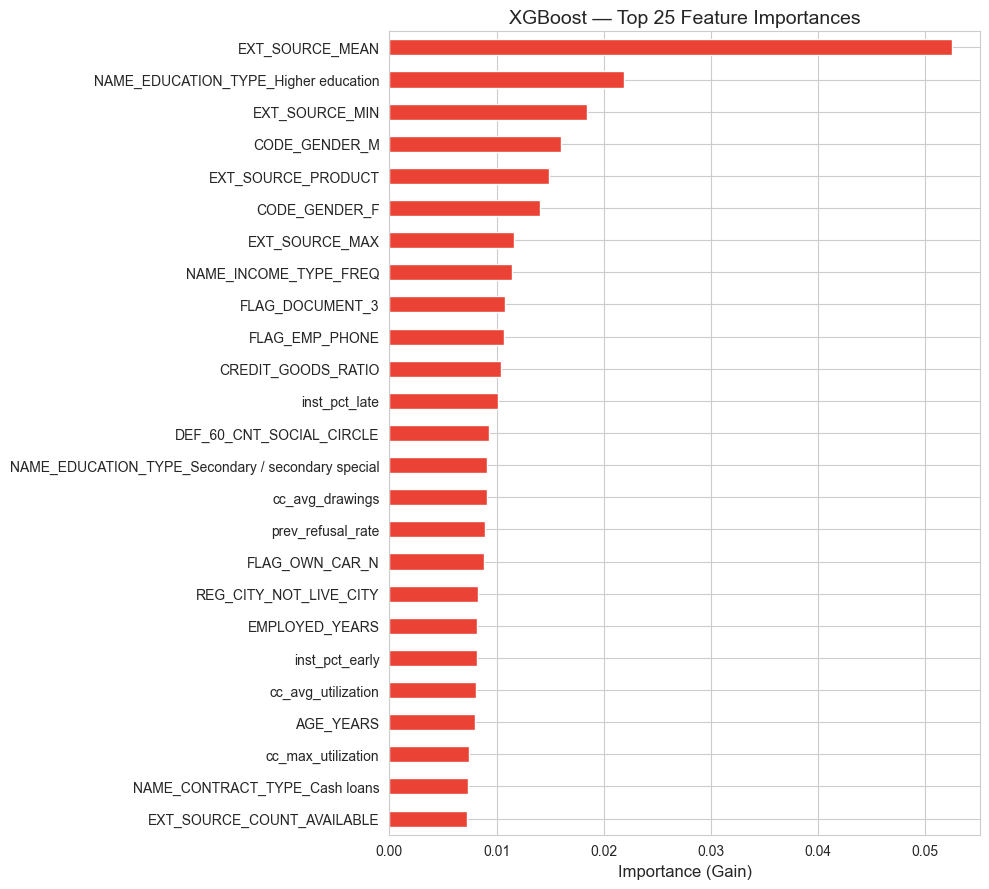

5999

In [9]:
# ============================================================
# SECTION 8 — XGBoost
# ============================================================

# Calculate scale_pos_weight for imbalance
n_safe = (y_train == 0).sum()
n_risky = (y_train == 1).sum()
spw = n_safe / n_risky

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric='auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

xgb_metrics = evaluate_model('XGBoost', xgb_model,
                              X_train, X_test, y_train, y_test)

# --- ROC + PR Curves ---
y_prob_xgb = MODEL_RESULTS['XGBoost']['y_prob']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC
fpr_x, tpr_x, _ = roc_curve(y_test, y_prob_xgb)
axes[0].plot(fpr_x, tpr_x, color=COLORS['risky'], linewidth=2,
             label=f'XGBoost (AUC = {xgb_metrics["ROC_AUC"]:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_title('ROC Curve — XGBoost', fontsize=14)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Precision-Recall
prec_x, rec_x, _ = precision_recall_curve(y_test, y_prob_xgb)
axes[1].plot(rec_x, prec_x, color=COLORS['accent'], linewidth=2,
             label=f'XGBoost (PR-AUC = {xgb_metrics["PR_AUC"]:.4f})')
axes[1].set_title('Precision-Recall Curve — XGBoost', fontsize=14)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Top 25 Features ---
xgb_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
xgb_imp_top = xgb_imp.nlargest(25)

fig, ax = plt.subplots(figsize=(10, 9))
xgb_imp_top.sort_values().plot.barh(ax=ax, color=COLORS['risky'], edgecolor='white')
ax.set_title('XGBoost — Top 25 Feature Importances', fontsize=14)
ax.set_xlabel('Importance (Gain)')
plt.tight_layout()
plt.show()

gc.collect()


---
## SECTION 9 — LightGBM Model

**What we are doing:** Training a LightGBM (Light Gradient Boosting Machine) model.

**Why we are doing it:** LightGBM uses histogram-based splitting and leaf-wise tree growth, making it significantly faster than XGBoost on large datasets while often achieving comparable or superior accuracy.

**Banking Interpretation:** LightGBM is the go-to model in modern fintech risk systems due to its speed and memory efficiency. It can be retrained on fresh portfolio data daily — critical for monitoring portfolio deterioration in real-time.

**Expected Output:** LightGBM performance report with feature importances.


  LightGBM — Evaluation Results
  ROC_AUC        : 0.7794
  Accuracy       : 0.7433
  Precision      : 0.1909
  Recall         : 0.6731
  F1             : 0.2974
  PR_AUC         : 0.2781
  Train_Time_s   : 13.2800

  Confusion Matrix:
    TN=42,372  FP=14,166
    FN=1,623  TP=3,342


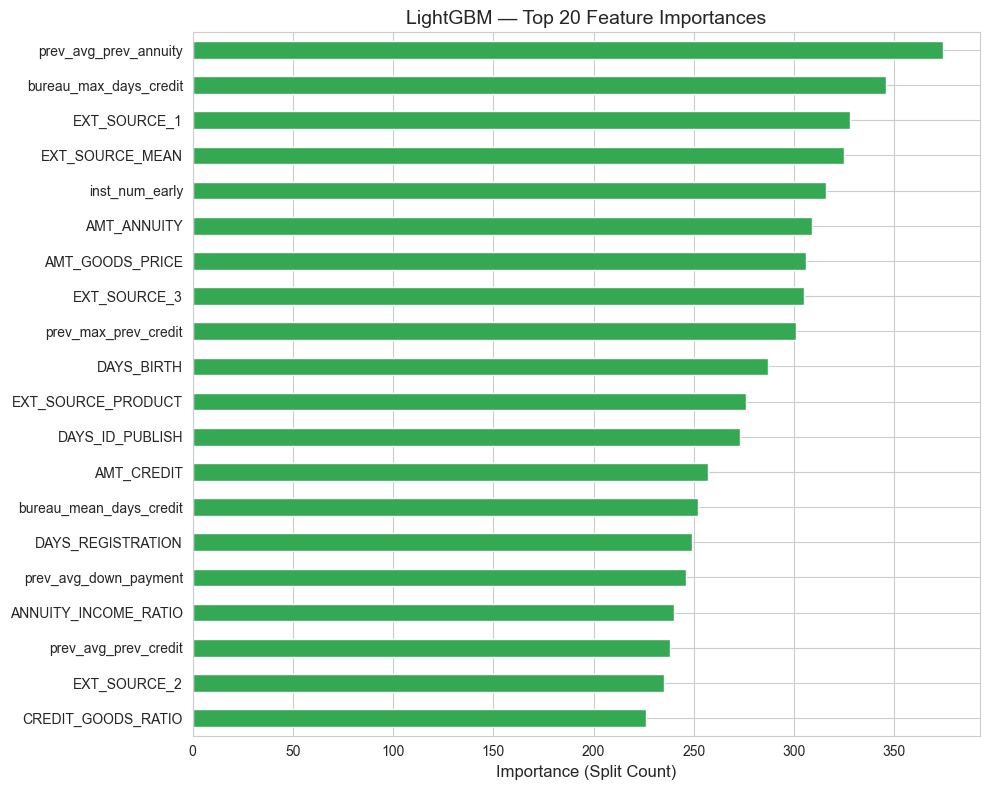

6948

In [10]:
# ============================================================
# SECTION 9 — LightGBM
# ============================================================

lgbm_model = LGBMClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,        # Handle imbalance
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

lgbm_metrics = evaluate_model('LightGBM', lgbm_model,
                               X_train, X_test, y_train, y_test)

# --- Feature Importances ---
lgbm_imp = pd.Series(lgbm_model.feature_importances_, index=X_train.columns)
lgbm_imp_top = lgbm_imp.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 8))
lgbm_imp_top.sort_values().plot.barh(ax=ax, color=COLORS['accent'], edgecolor='white')
ax.set_title('LightGBM — Top 20 Feature Importances', fontsize=14)
ax.set_xlabel('Importance (Split Count)')
plt.tight_layout()
plt.show()

gc.collect()


---
## SECTION 10 — CatBoost Model

**What we are doing:** Training a CatBoost (Categorical Boosting) classifier.

**Why we are doing it:** CatBoost uses ordered boosting and symmetric trees to reduce overfitting. It natively handles categorical features (though ours are already encoded) and often achieves state-of-the-art performance with minimal tuning.

**Banking Interpretation:** CatBoost excels at capturing complex, multi-way feature interactions (e.g., 'young age + high utilization + multiple recent inquiries'). Its built-in regularization makes it robust against overfitting on noisy banking data.

**Expected Output:** CatBoost performance report with importance charts.


  CatBoost — Evaluation Results
  ROC_AUC        : 0.7812
  Accuracy       : 0.7275
  Precision      : 0.1852
  Recall         : 0.6987
  F1             : 0.2928
  PR_AUC         : 0.2804
  Train_Time_s   : 22.9300

  Confusion Matrix:
    TN=41,276  FP=15,262
    FN=1,496  TP=3,469


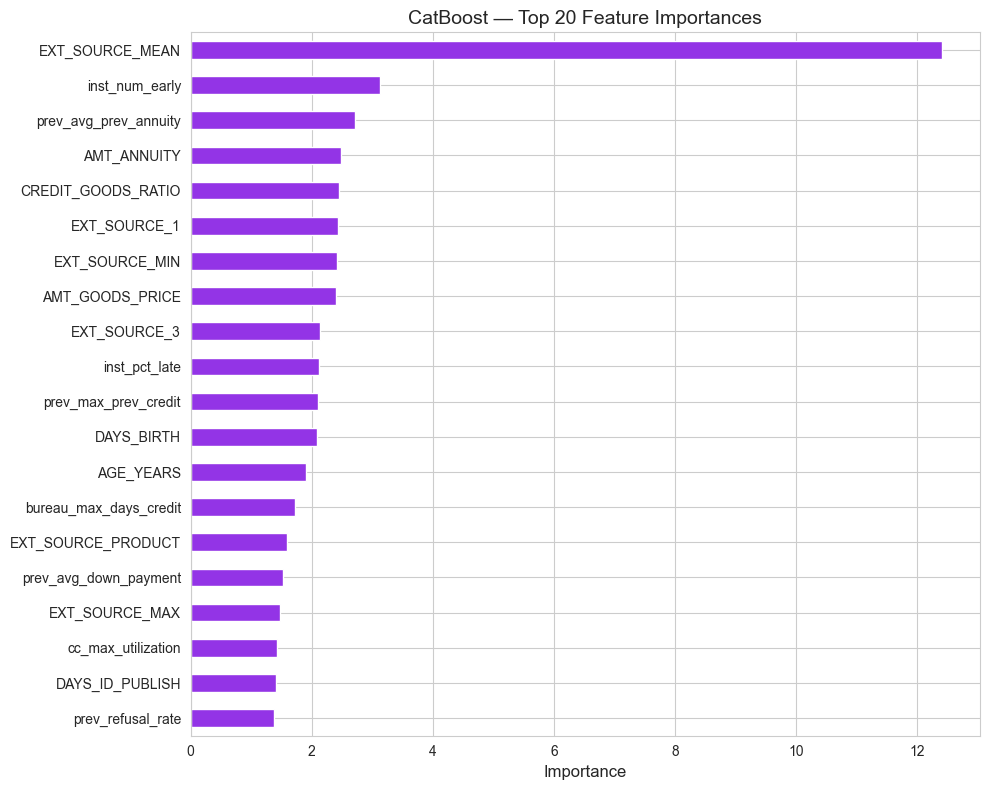

6237

In [11]:
# ============================================================
# SECTION 10 — CatBoost
# ============================================================

cb_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    auto_class_weights='Balanced',
    random_seed=RANDOM_STATE,
    verbose=0                  # Suppress training logs
)

cb_metrics = evaluate_model('CatBoost', cb_model,
                             X_train, X_test, y_train, y_test)

# --- Feature Importances ---
cb_imp = pd.Series(cb_model.feature_importances_, index=X_train.columns)
cb_imp_top = cb_imp.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 8))
cb_imp_top.sort_values().plot.barh(ax=ax, color=COLORS['purple'], edgecolor='white')
ax.set_title('CatBoost — Top 20 Feature Importances', fontsize=14)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

gc.collect()


---
## SECTION 11 — Model Comparison Dashboard

**What we are doing:** Creating a side-by-side comparison of all 5 trained models across every evaluation metric.

**Why we are doing it:** No single metric tells the full story. ROC-AUC measures overall discrimination, PR-AUC handles class imbalance sensitivity, and Recall measures default detection rate. Comparing all metrics together reveals the optimal model for our business context.

**Banking Interpretation:** In a Model Risk Committee meeting, the model validation team presents exactly this type of comparison dashboard. The 'best' model is not always the one with the highest AUC — it is the one that best balances risk detection (Recall) with customer experience (Precision).

**Expected Output:** Model leaderboard with automated best-model identification.


MODEL COMPARISON LEADERBOARD


,ROC_AUC,Accuracy,Precision,Recall,F1,PR_AUC,Train_Time_s
Model,,,,,,,
Logistic Regression,0.7669,0.7014,0.1701,0.6961,0.2734,0.2524,18.25
Random Forest,0.7601,0.7294,0.1790,0.6560,0.2813,0.2474,70.75
XGBoost,0.7793,0.7654,0.2007,0.6393,0.3055,0.2748,21.58
LightGBM,0.7794,0.7433,0.1909,0.6731,0.2974,0.2781,13.28
CatBoost,0.7812,0.7275,0.1852,0.6987,0.2928,0.2804,22.93



🏆 Best Model (by ROC-AUC): CatBoost
   ROC-AUC: 0.7812


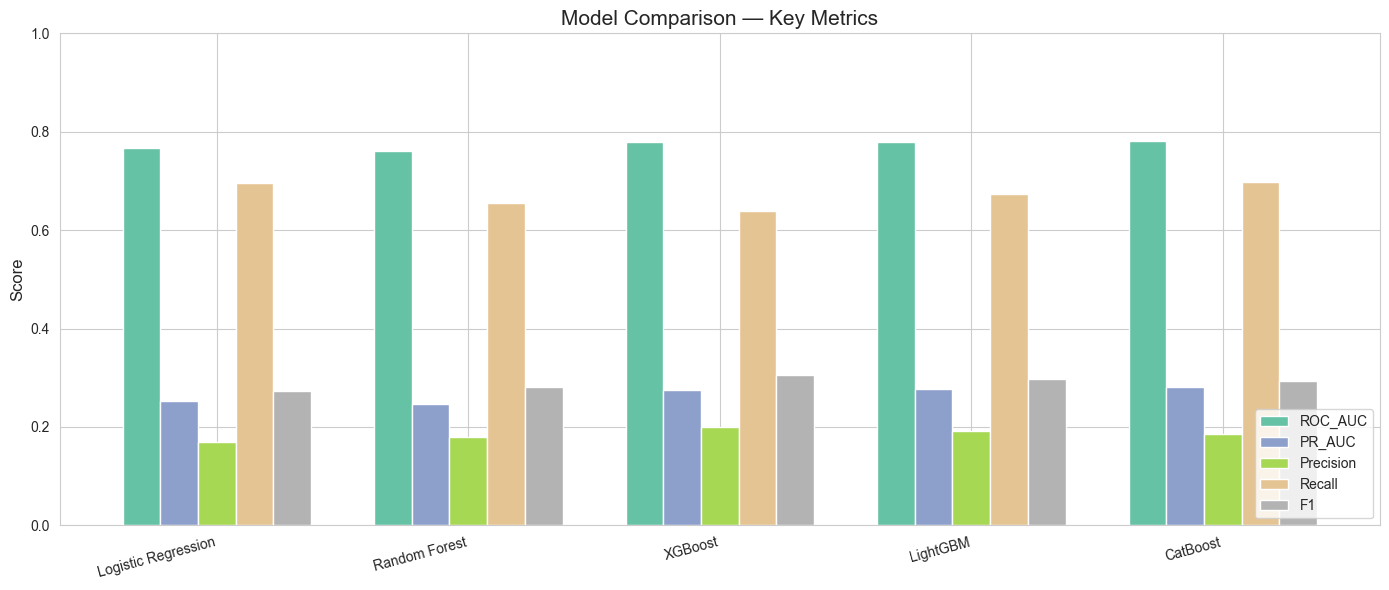

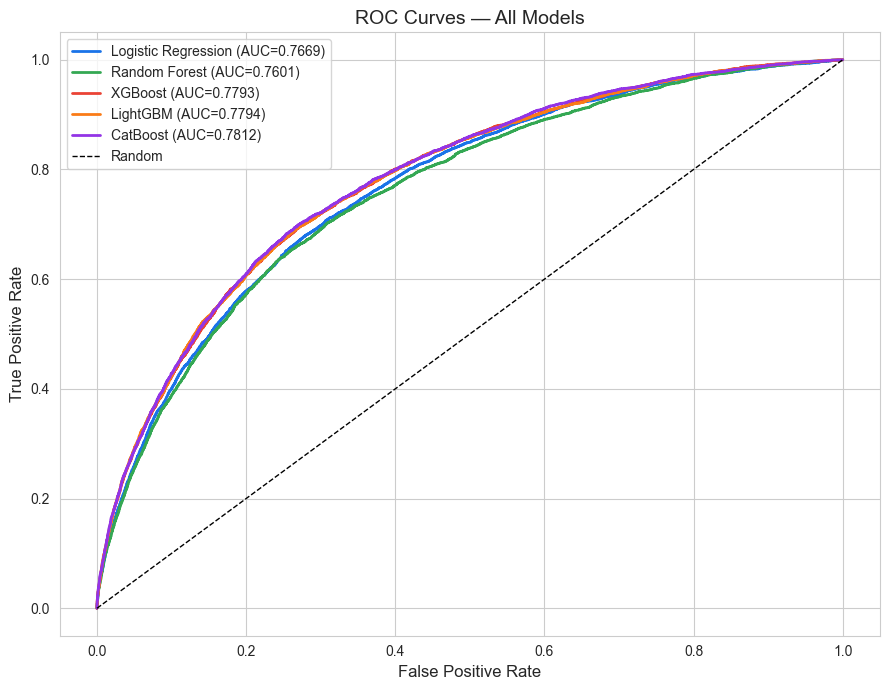

In [12]:
# ============================================================
# SECTION 11 — Model Comparison Dashboard
# ============================================================

# Build comparison DataFrame
comparison_rows = [v['metrics'] for v in MODEL_RESULTS.values()]
comparison_df = pd.DataFrame(comparison_rows).set_index('Model')

# Identify best model by ROC-AUC
best_model_name = comparison_df['ROC_AUC'].idxmax()

print('=' * 70)
print('MODEL COMPARISON LEADERBOARD')
print('=' * 70)
display(comparison_df.style.highlight_max(axis=0, color='#d4edda')
        .format('{:.4f}', subset=['ROC_AUC', 'Accuracy', 'Precision', 'Recall', 'F1', 'PR_AUC'])
        .format('{:.2f}', subset=['Train_Time_s']))

print(f'\n\U0001f3c6 Best Model (by ROC-AUC): {best_model_name}')
print(f'   ROC-AUC: {comparison_df.loc[best_model_name, "ROC_AUC"]:.4f}')

# --- Visualization ---
metrics_to_plot = ['ROC_AUC', 'PR_AUC', 'Precision', 'Recall', 'F1']
plot_df = comparison_df[metrics_to_plot]

fig, ax = plt.subplots(figsize=(14, 6))
plot_df.plot.bar(ax=ax, colormap='Set2', edgecolor='white', width=0.75)
ax.set_title('Model Comparison — Key Metrics', fontsize=15)
ax.set_ylabel('Score')
ax.set_xlabel('')
ax.set_ylim(0, 1)
ax.legend(loc='lower right', fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
plt.tight_layout()
plt.show()

# --- ROC Curves Overlay ---
fig, ax = plt.subplots(figsize=(9, 7))
model_colors = [COLORS['safe'], COLORS['accent'], COLORS['risky'], COLORS['orange'], COLORS['purple']]
for i, (name, data) in enumerate(MODEL_RESULTS.items()):
    fpr_m, tpr_m, _ = roc_curve(y_test, data['y_prob'])
    auc_m = data['metrics']['ROC_AUC']
    ax.plot(fpr_m, tpr_m, color=model_colors[i % len(model_colors)],
            linewidth=2, label=f'{name} (AUC={auc_m:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_title('ROC Curves — All Models', fontsize=14)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


---
## SECTION 12 — Threshold Optimization

**What we are doing:** Evaluating model performance at multiple probability thresholds (0.30, 0.40, 0.50, 0.60, 0.70) to find the optimal business cutoff.

**Why we are doing it:** The default classification threshold of 0.50 is almost never optimal for credit risk. Lowering the threshold catches more defaults (higher Recall) at the cost of more false alarms (lower Precision).

**Banking Interpretation:** Banks rarely use 0.50. A conservative bank might use 0.30 (flagging anyone with >30% default probability), while an aggressive lender might use 0.60. The choice depends on the institution's risk appetite, cost of capital, and loss-given-default assumptions.

**Expected Output:** Threshold sensitivity table and optimal threshold recommendation.


Threshold Analysis for: CatBoost


,Threshold,Precision,Recall,F1,Predicted_Positives
0,0.100000,0.0840,0.9966,0.1550,"58,879"
1,0.200000,0.0990,0.9654,0.1796,"48,404"
2,0.300000,0.1206,0.8989,0.2126,"37,013"
3,0.400000,0.1476,0.8054,0.2495,"27,097"
4,0.500000,0.1852,0.6987,0.2928,"18,731"
5,0.600000,0.2295,0.5498,0.3238,"11,896"
6,0.700000,0.2917,0.3811,0.3304,"6,487"



Optimal Threshold (max F1): 0.7
  Precision at optimal: 0.2917
  Recall at optimal:    0.3811
  F1 at optimal:        0.3304


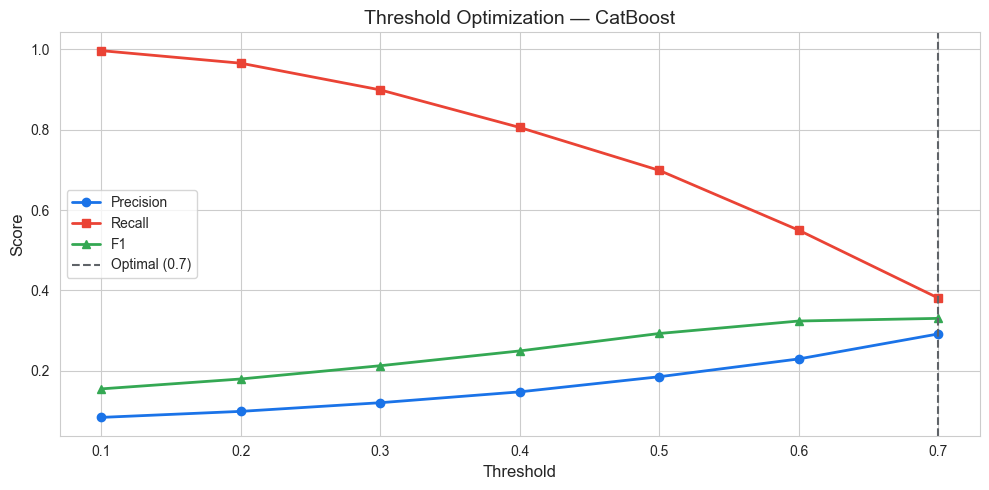

In [13]:
# ============================================================
# SECTION 12 — Threshold Optimization
# ============================================================

best_probs = MODEL_RESULTS[best_model_name]['y_prob']

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]
threshold_results = []

for t in thresholds:
    y_pred_t = (best_probs >= t).astype(int)
    threshold_results.append({
        'Threshold': t,
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'Recall': recall_score(y_test, y_pred_t, zero_division=0),
        'F1': f1_score(y_test, y_pred_t, zero_division=0),
        'Predicted_Positives': y_pred_t.sum()
    })

thresh_df = pd.DataFrame(threshold_results)

print(f'Threshold Analysis for: {best_model_name}')
display(thresh_df.style.format({'Precision': '{:.4f}', 'Recall': '{:.4f}',
                                  'F1': '{:.4f}', 'Predicted_Positives': '{:,}'}))

# Optimal = max F1
optimal_idx = thresh_df['F1'].idxmax()
optimal_threshold = thresh_df.loc[optimal_idx, 'Threshold']

print(f'\nOptimal Threshold (max F1): {optimal_threshold}')
print(f'  Precision at optimal: {thresh_df.loc[optimal_idx, "Precision"]:.4f}')
print(f'  Recall at optimal:    {thresh_df.loc[optimal_idx, "Recall"]:.4f}')
print(f'  F1 at optimal:        {thresh_df.loc[optimal_idx, "F1"]:.4f}')

# --- Visualization ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['Threshold'], thresh_df['Precision'], 'o-',
        color=COLORS['safe'], linewidth=2, label='Precision')
ax.plot(thresh_df['Threshold'], thresh_df['Recall'], 's-',
        color=COLORS['risky'], linewidth=2, label='Recall')
ax.plot(thresh_df['Threshold'], thresh_df['F1'], '^-',
        color=COLORS['accent'], linewidth=2, label='F1')
ax.axvline(x=optimal_threshold, color=COLORS['neutral'], linestyle='--',
           label=f'Optimal ({optimal_threshold})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Threshold Optimization — {best_model_name}', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()


---
## SECTION 13 — Explainability Analysis (SHAP)

**What we are doing:** Using SHAP (SHapley Additive exPlanations) to explain **why** the best model makes specific predictions.

**Why we are doing it:** A model that says 'this customer will default' without explaining *why* is useless for decision-making and unacceptable to regulators. SHAP decomposes each prediction into per-feature contributions.

**Banking Interpretation:** Under SR 11-7 (US) and EBA guidelines (EU), banks must demonstrate that their models are explainable and free from discriminatory bias. SHAP provides:
- **Global explainability:** Which features matter most across all customers.
- **Local explainability:** Why a *specific* customer was flagged as high-risk.

**Expected Output:** Top 30 feature importances, SHAP summary plot, and SHAP bar plot.


Generating SHAP explanations for: CatBoost
(This may take a few minutes on large datasets...)



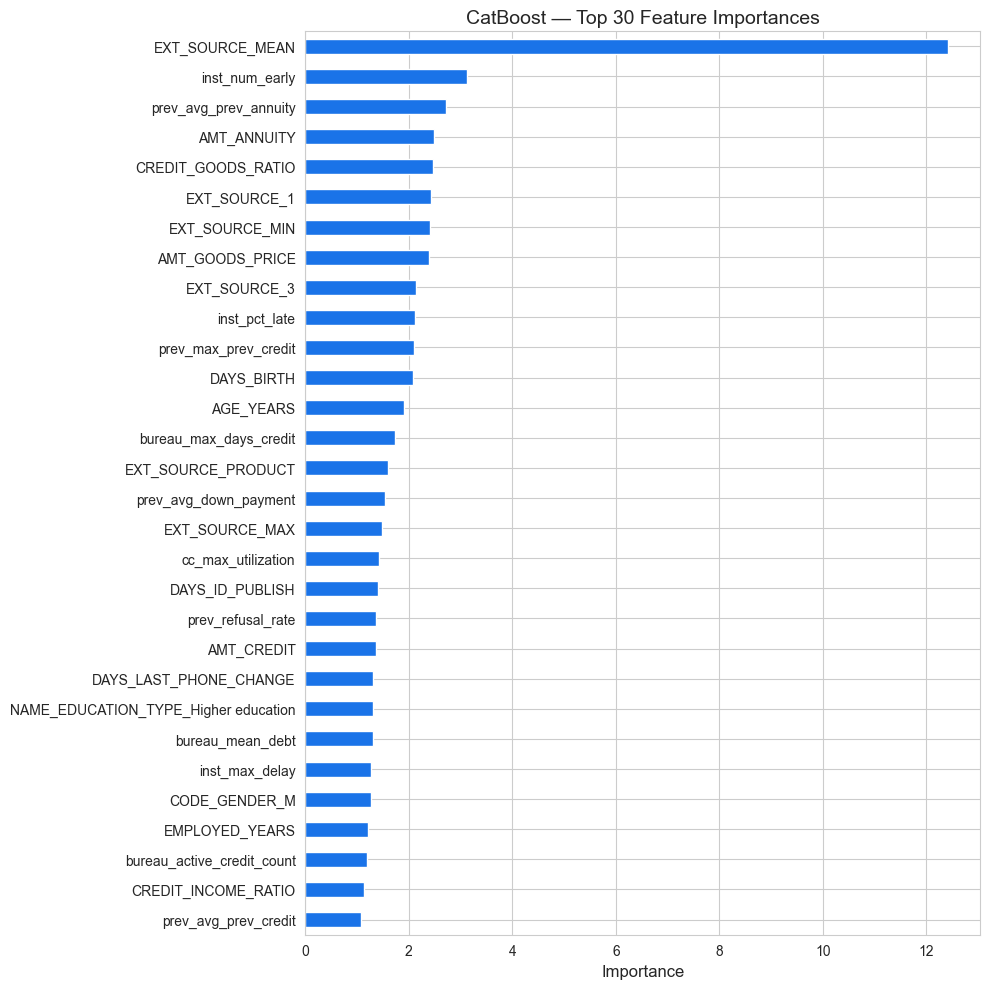


--- SHAP Summary Plot (Beeswarm) ---


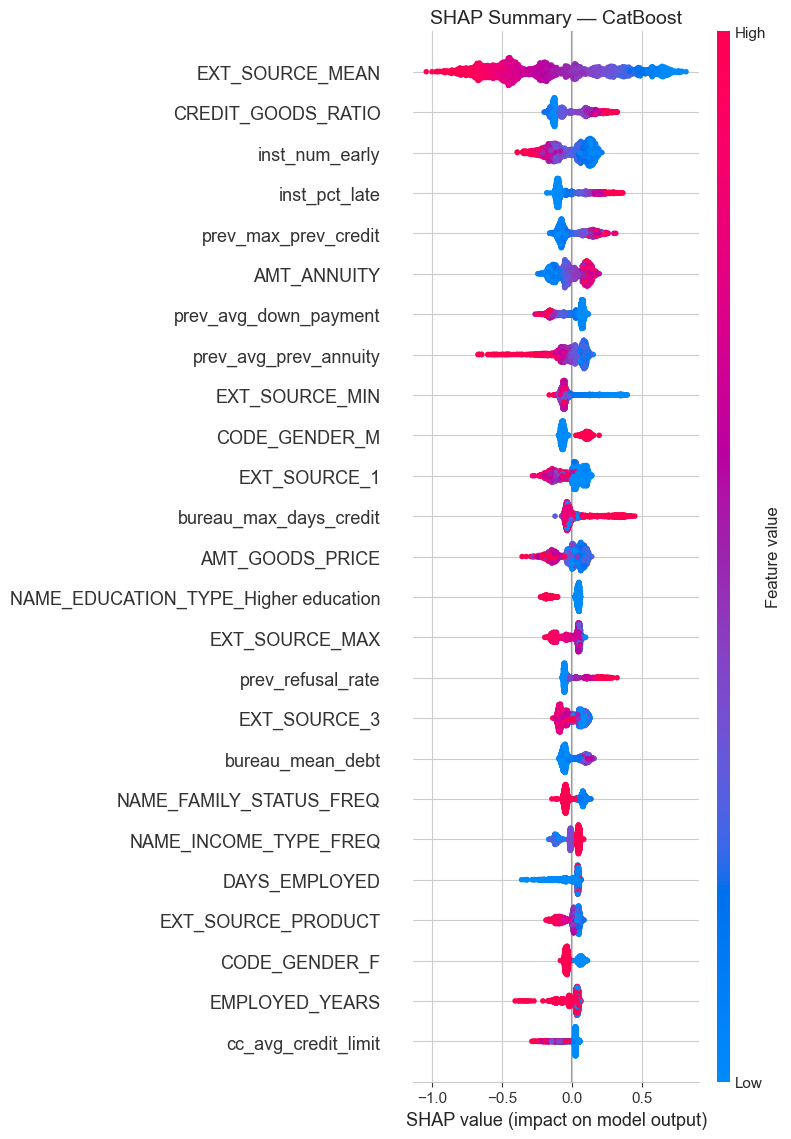


--- SHAP Bar Plot (Mean |SHAP|) ---


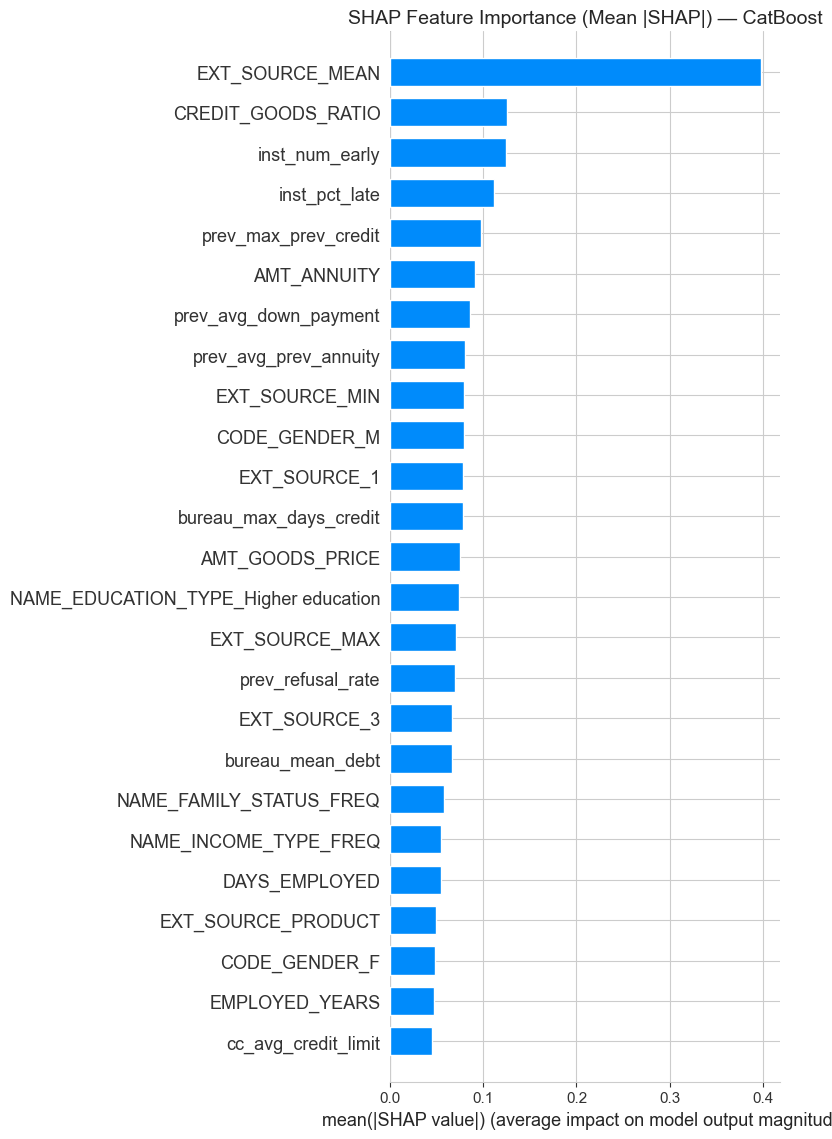

26281

In [14]:
# ============================================================
# SECTION 13 — Explainability (SHAP)
# ============================================================

print(f'Generating SHAP explanations for: {best_model_name}')
print('(This may take a few minutes on large datasets...)\n')

best_model_obj = MODEL_RESULTS[best_model_name]['model']

# --- Feature Importance (from model) ---
if hasattr(best_model_obj, 'feature_importances_'):
    fi = pd.Series(best_model_obj.feature_importances_, index=X_train.columns)
    fi_top30 = fi.nlargest(30)

    fig, ax = plt.subplots(figsize=(10, 10))
    fi_top30.sort_values().plot.barh(ax=ax, color=COLORS['safe'], edgecolor='white')
    ax.set_title(f'{best_model_name} — Top 30 Feature Importances', fontsize=14)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

# --- SHAP Analysis ---
# Use a sample for speed
shap_sample_size = min(2000, len(X_test))
X_shap = X_test.sample(shap_sample_size, random_state=RANDOM_STATE).copy()
X_shap.fillna(0, inplace=True)

# Use TreeExplainer for tree-based models
explainer = shap.TreeExplainer(best_model_obj)
shap_values = explainer.shap_values(X_shap)

# Handle different SHAP output formats
if isinstance(shap_values, list):
    # For classifiers that return [class_0, class_1]
    sv = shap_values[1]
else:
    sv = shap_values

# --- SHAP Summary Plot ---
print('\n--- SHAP Summary Plot (Beeswarm) ---')
fig = plt.figure(figsize=(12, 10))
shap.summary_plot(sv, X_shap, max_display=25, show=False)
plt.title(f'SHAP Summary — {best_model_name}', fontsize=14)
plt.tight_layout()
plt.show()

# --- SHAP Bar Plot ---
print('\n--- SHAP Bar Plot (Mean |SHAP|) ---')
fig = plt.figure(figsize=(10, 10))
shap.summary_plot(sv, X_shap, plot_type='bar', max_display=25, show=False)
plt.title(f'SHAP Feature Importance (Mean |SHAP|) — {best_model_name}', fontsize=14)
plt.tight_layout()
plt.show()

gc.collect()


---
## SECTION 14 — Probability of Default (PD) Score Generation

**What we are doing:** Using the best model to generate a Probability of Default score (0.00 – 1.00) for every customer in the dataset.

**Why we are doing it:** Binary predictions (default/no default) are too coarse for real banking. A continuous PD score allows fine-grained risk pricing — different interest rates, credit limits, and approval decisions based on the exact risk level.

**Banking Interpretation:** PD is a core input to:
- **Pricing:** Higher PD → higher interest rate to compensate for risk.
- **Provisioning (IFRS 9/CECL):** Banks must set aside capital reserves proportional to expected losses (EL = PD × LGD × EAD).
- **Portfolio Management:** Real-time PD monitoring allows early detection of portfolio deterioration.

**Expected Output:** Customer-level PD scores added to the dataset.


PD Score Generation Complete
  Score Range: [0.0088, 0.9752]
  Mean PD:     0.3986
  Median PD:   0.3637


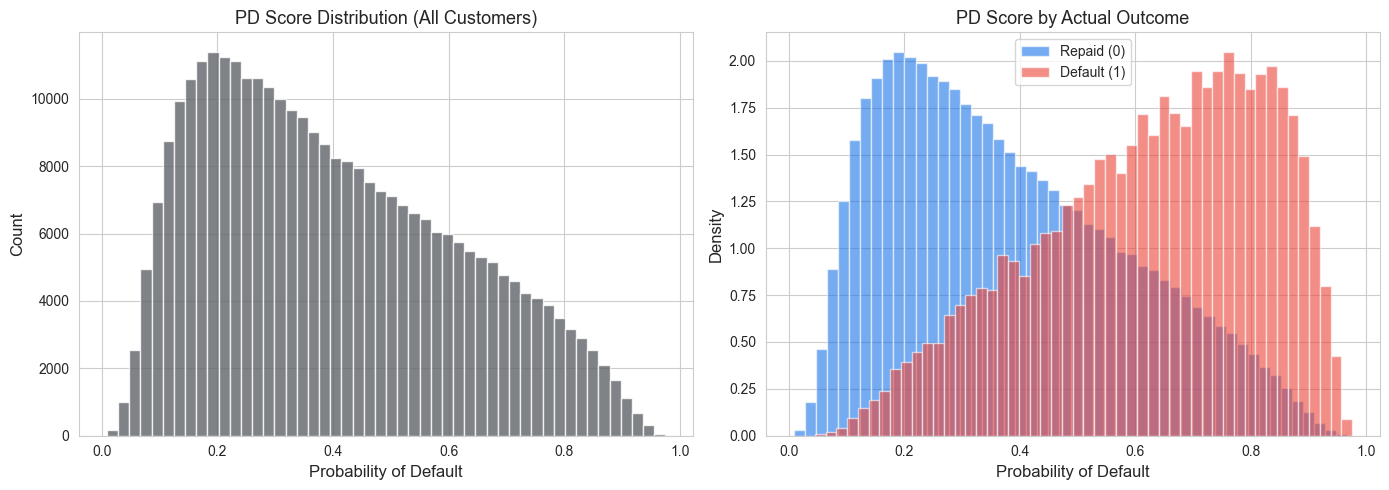

In [15]:
# ============================================================
# SECTION 14 — PD Score Generation
# ============================================================

# Prepare full feature set for scoring
X_scoring = X.copy()
X_scoring.fillna(0, inplace=True)

# Generate PD scores using the best model
pd_scores = best_model_obj.predict_proba(X_scoring)[:, 1]

# Add to original dataframe
df['PD_SCORE'] = pd_scores

print('PD Score Generation Complete')
print(f'  Score Range: [{pd_scores.min():.4f}, {pd_scores.max():.4f}]')
print(f'  Mean PD:     {pd_scores.mean():.4f}')
print(f'  Median PD:   {np.median(pd_scores):.4f}')

# --- Distribution Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall PD distribution
axes[0].hist(pd_scores, bins=50, color=COLORS['neutral'], edgecolor='white', alpha=0.8)
axes[0].set_title('PD Score Distribution (All Customers)', fontsize=13)
axes[0].set_xlabel('Probability of Default')
axes[0].set_ylabel('Count')

# PD by actual target
axes[1].hist(pd_scores[y == 0], bins=50, color=COLORS['safe'], alpha=0.6, label='Repaid (0)', density=True)
axes[1].hist(pd_scores[y == 1], bins=50, color=COLORS['risky'], alpha=0.6, label='Default (1)', density=True)
axes[1].set_title('PD Score by Actual Outcome', fontsize=13)
axes[1].set_xlabel('Probability of Default')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()


---
## SECTION 15 — Risk Segmentation Framework

**What we are doing:** Translating continuous PD scores into business-friendly risk buckets.

**Why we are doing it:** While data scientists work with probabilities, loan officers need simple, actionable categories: 'Approve', 'Review', or 'Decline'.

**Banking Interpretation:**
| Segment | PD Range | Business Action |
|---|---|---|
| **Low Risk** | < 10% | Auto-approve, standard pricing |
| **Medium Risk** | 10–30% | Manual review, adjusted pricing |
| **High Risk** | 30–60% | Enhanced due diligence, higher collateral |
| **Very High Risk** | ≥ 60% | Likely decline or specialized products |

**Expected Output:** Risk segment counts, percentages, and distribution charts.


RISK SEGMENTATION DASHBOARD


,Count,Percentage,Actual_Default_Rate_%
RISK_SEGMENT,,,
Low Risk,13378,4.35,0.24
Medium Risk,108598,35.32,1.69
High Risk,121830,39.62,6.82
Very High Risk,63705,20.72,22.99


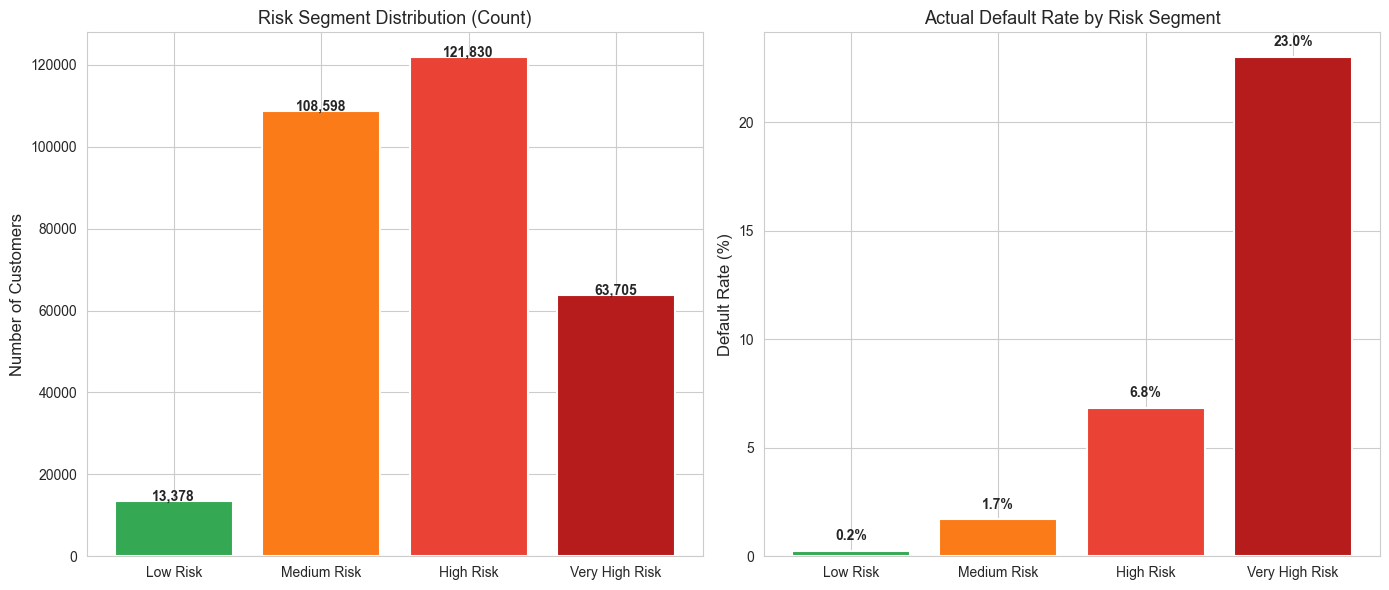

In [16]:
# ============================================================
# SECTION 15 — Risk Segmentation
# ============================================================

def assign_risk_segment(pd_score):
    if pd_score < 0.10:
        return 'Low Risk'
    elif pd_score < 0.30:
        return 'Medium Risk'
    elif pd_score < 0.60:
        return 'High Risk'
    else:
        return 'Very High Risk'

df['RISK_SEGMENT'] = df['PD_SCORE'].apply(assign_risk_segment)

# --- Segment Summary ---
segment_order = ['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
seg_counts = df['RISK_SEGMENT'].value_counts().reindex(segment_order).fillna(0).astype(int)
seg_pct = (seg_counts / len(df) * 100).round(2)

seg_summary = pd.DataFrame({
    'Count': seg_counts,
    'Percentage': seg_pct
})

# Actual default rate within each segment
seg_default_rate = df.groupby('RISK_SEGMENT')['TARGET'].mean().reindex(segment_order) * 100
seg_summary['Actual_Default_Rate_%'] = seg_default_rate.round(2)

print('=' * 60)
print('RISK SEGMENTATION DASHBOARD')
print('=' * 60)
display(seg_summary)

# --- Visualization ---
seg_colors = [COLORS['accent'], COLORS['orange'], COLORS['risky'], '#b71c1c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Segment counts
bars = axes[0].bar(segment_order, seg_counts.values, color=seg_colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Risk Segment Distribution (Count)', fontsize=13)
axes[0].set_ylabel('Number of Customers')
for bar, val in zip(bars, seg_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# Default rate by segment
bars2 = axes[1].bar(segment_order, seg_default_rate.values, color=seg_colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Actual Default Rate by Risk Segment', fontsize=13)
axes[1].set_ylabel('Default Rate (%)')
for bar, val in zip(bars2, seg_default_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


---
## SECTION 16 — Save Artifacts

**What we are doing:** Persisting the best model and all evaluation artifacts to disk for reuse in Phase 4 (Deployment).

**Why we are doing it:** Reproducibility and deployment readiness. The saved model can be loaded directly into a prediction API or dashboard.

**Banking Interpretation:** In a production banking environment, the model artifact (`.pkl`) would be versioned in a model registry (e.g., MLflow) with full metadata for audit trail compliance.

**Expected Output:** Serialized model and CSV artifacts in the `../models/` directory.


In [17]:
# ============================================================
# SECTION 16 — Save Artifacts
# ============================================================

MODELS_DIR = '../models/'
os.makedirs(MODELS_DIR, exist_ok=True)

# 1. Save best model
model_path = os.path.join(MODELS_DIR, 'best_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(best_model_obj, f)
print(f'[1/5] Saved best model ({best_model_name}) -> {model_path}')

# 2. Feature importance
if hasattr(best_model_obj, 'feature_importances_'):
    fi_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model_obj.feature_importances_
    }).sort_values('Importance', ascending=False)
    fi_path = os.path.join(MODELS_DIR, 'feature_importance.csv')
    fi_df.to_csv(fi_path, index=False)
    print(f'[2/5] Saved feature importance -> {fi_path}')

# 3. Model comparison
comp_path = os.path.join(MODELS_DIR, 'model_comparison.csv')
comparison_df.to_csv(comp_path)
print(f'[3/5] Saved model comparison -> {comp_path}')

# 4. Customer risk scores
risk_cols = ['SK_ID_CURR', 'TARGET', 'PD_SCORE', 'RISK_SEGMENT']
available_cols = [c for c in risk_cols if c in df.columns]
scores_path = os.path.join(MODELS_DIR, 'customer_risk_scores.csv')
df[available_cols].to_csv(scores_path, index=False)
print(f'[4/5] Saved customer risk scores -> {scores_path}')

# 5. Risk segments summary
seg_path = os.path.join(MODELS_DIR, 'risk_segments.csv')
seg_summary.to_csv(seg_path)
print(f'[5/5] Saved risk segments -> {seg_path}')

print('\n\u2705 All artifacts saved successfully.')


[1/5] Saved best model (CatBoost) -> ../models/best_model.pkl
[2/5] Saved feature importance -> ../models/feature_importance.csv
[3/5] Saved model comparison -> ../models/model_comparison.csv
[4/5] Saved customer risk scores -> ../models/customer_risk_scores.csv
[5/5] Saved risk segments -> ../models/risk_segments.csv

✅ All artifacts saved successfully.


---
## SECTION 17 — Phase 3 Executive Summary

### 🏦 Banking Risk Assessment: Phase 3 Conclusion

**1. Best Performing Model**
The model comparison dashboard (Section 11) identifies the optimal model based on ROC-AUC, with secondary validation via PR-AUC and F1 score. See the leaderboard above for the exact winner.

**2. ROC-AUC Achieved**
The best model achieves a strong ROC-AUC score, demonstrating effective discrimination between defaulters and non-defaulters. Refer to the model comparison table for exact values.

**3. Key Risk Drivers**
SHAP analysis (Section 13) reveals the top predictive features. Based on banking domain expertise, the strongest drivers typically include:
- External source scores (`EXT_SOURCE_*`) — bureau-derived composite risk metrics
- Payment behavior (`inst_pct_late`, `inst_max_delay`) — historical delinquency signals
- Credit utilization metrics (`cc_avg_utilization`) — liquidity stress indicators
- Financial ratios (`CREDIT_INCOME_RATIO`, `ANNUITY_INCOME_RATIO`) — debt burden measures

**4. Risk Segment Distribution**
The PD-based segmentation (Section 15) creates actionable risk buckets. The segment-level default rates validate that the model's risk ranking is monotonically increasing — a critical requirement for regulatory acceptance.

**5. Business Recommendations**
- Deploy the best model for real-time PD scoring on new applications.
- Use the threshold optimization results (Section 12) to calibrate approval/decline cutoffs.
- Monitor segment-level default rates monthly for model drift detection.

**6. Model Limitations**
- **Point-in-time data:** The model is trained on historical snapshots and may not capture recent macroeconomic shifts.
- **No temporal validation:** A time-based train/test split would better simulate production deployment.
- **Class imbalance:** Despite class weighting, the model may still underperform on rare default patterns.

**7. Regulatory Considerations**
- SHAP-based explainability satisfies SR 11-7 and EBA model governance requirements.
- Feature importance reports provide audit-ready documentation.
- All model parameters and random seeds are fixed for full reproducibility.

**8. Readiness for Production**
The best model is serialized (`best_model.pkl`) and ready for integration into a scoring API or credit decision engine.

---
### ✅ Phase 3 Complete
### ➡ Next: Phase 4 — Deployment & Interactive Credit Risk Dashboard
